In [5]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = "https://api.openbrewerydb.org/v1/breweries"
PER_PAGE = 200
PAGES = 3


def fetch_all_breweries(pages=PAGES, per_page=PER_PAGE):
    records = []
    for page in range(1, pages + 1):
        resp = requests.get(BASE, params={"page": page, "per_page": per_page})
        resp.raise_for_status()
        items = resp.json()
        if not items:
            break
        for b in items:
            name = b.get("name") or ""
            record = {
                "id": b.get("id"),
                "name": name,
                "brewery_type": b.get("brewery_type"),
                "city": b.get("city"),
                "state_province": b.get("state_province"),
                "country": b.get("country"),
                "latitude": b.get("latitude"),
                "longitude": b.get("longitude"),
                "has_website": 1 if b.get("website_url") else 0,
                "has_phone": 1 if b.get("phone") else 0,
                "name_length": len(name),
                "num_words_name": len(name.split()),
            }
            records.append(record)
        print(f"Fetched page {page} ({len(records)} total)")
        time.sleep(0.2)
    return records


records = fetch_all_breweries()
df_raw = pd.DataFrame(records)
df_raw.to_csv("raw_data.csv", index=False)
print(df_raw.shape)
df_raw.head()


Fetched page 1 (200 total)
Fetched page 2 (400 total)
Fetched page 3 (600 total)
(600, 12)


,id,name,brewery_type,city,state_province,country,latitude,longitude,has_website,has_phone,name_length,num_words_name
0,ae7b3174-8be8-4d53-a3a5-9b8240970eea,'s,brewpub,Kronach,Bayern,Germany,50.241246,11.327765,1,1,2,1
1,aa7cbe9b-3a0f-4888-9884-6186b0042b55,’t Drankorgel,micro,Mol,Vlaanderen,Belgium,51.176258,5.056955,1,1,13,2
2,1034754f-abf9-4b42-bd6d-37e110ba4b1a,'T Kroontje,micro,Lebbeke,Vlaanderen,Belgium,51.007888,4.091393,1,1,11,2
3,5128df48-79fc-4f0f-8b52-d06be54d0cec,(405) Brewing Co,micro,Norman,Oklahoma,United States,35.257389,-97.468182,1,1,16,3
4,9c5a66c8-cc13-416f-a5d9-0a769c87d318,(512) Brewing Co,micro,Austin,Texas,United States,NaN,NaN,1,1,16,3


In [6]:
FEATURES = ["latitude", "longitude", "has_website", "has_phone", "name_length", "num_words_name"]
TARGET = "brewery_type"

df_raw.info()
print("\nMissing values:\n", df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nClass counts:\n", df_raw[TARGET].value_counts())
df_raw.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              600 non-null    object 
 1   name            600 non-null    object 
 2   brewery_type    600 non-null    object 
 3   city            600 non-null    object 
 4   state_province  600 non-null    object 
 5   country         600 non-null    object 
 6   latitude        479 non-null    float64
 7   longitude       479 non-null    float64
 8   has_website     600 non-null    int64  
 9   has_phone       600 non-null    int64  
 10  name_length     600 non-null    int64  
 11  num_words_name  600 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 56.4+ KB

Missing values:
 id                  0
name                0
brewery_type        0
city                0
state_province      0
country             0
latitude          121
longitude         121
has_webs

,latitude,longitude,has_website,has_phone,name_length,num_words_name
count,479.000000,479.000000,600.000000,600.000000,600.000000,600.000000
mean,37.241312,-62.580867,0.878333,0.913333,19.941667,3.171667
std,19.707095,69.541282,0.327173,0.281581,7.541422,1.250922
min,-45.717790,-157.857248,0.000000,0.000000,2.000000,1.000000
25%,36.140800,-116.822516,1.000000,1.000000,15.000000,2.000000
50%,41.508210,-85.537819,1.000000,1.000000,19.000000,3.000000
75%,47.355357,-0.170516,1.000000,1.000000,24.000000,4.000000
max,63.864759,175.251568,1.000000,1.000000,47.000000,8.000000


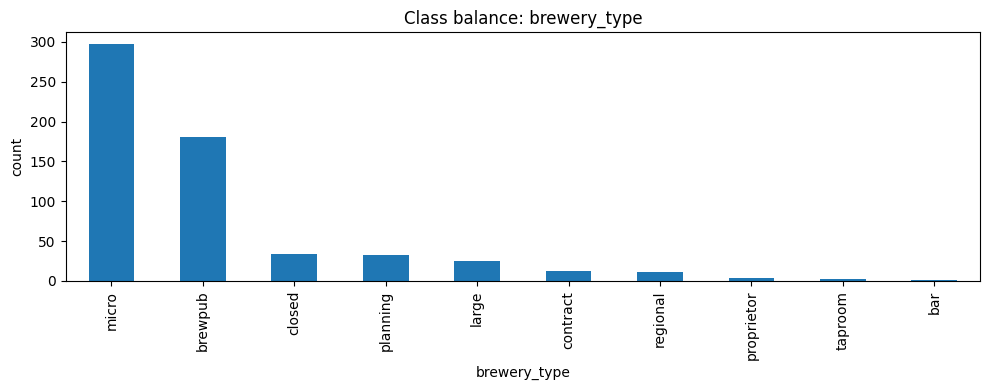

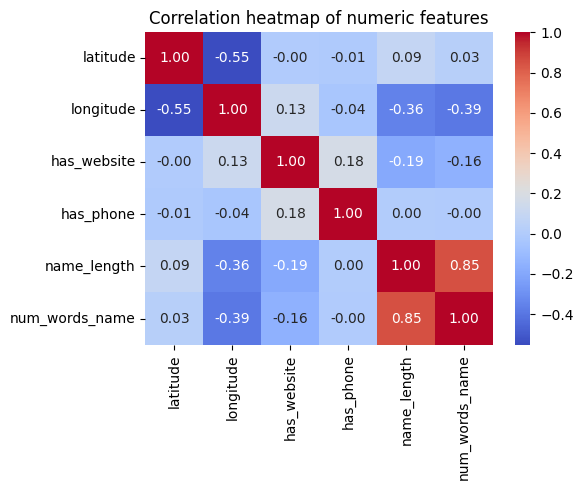

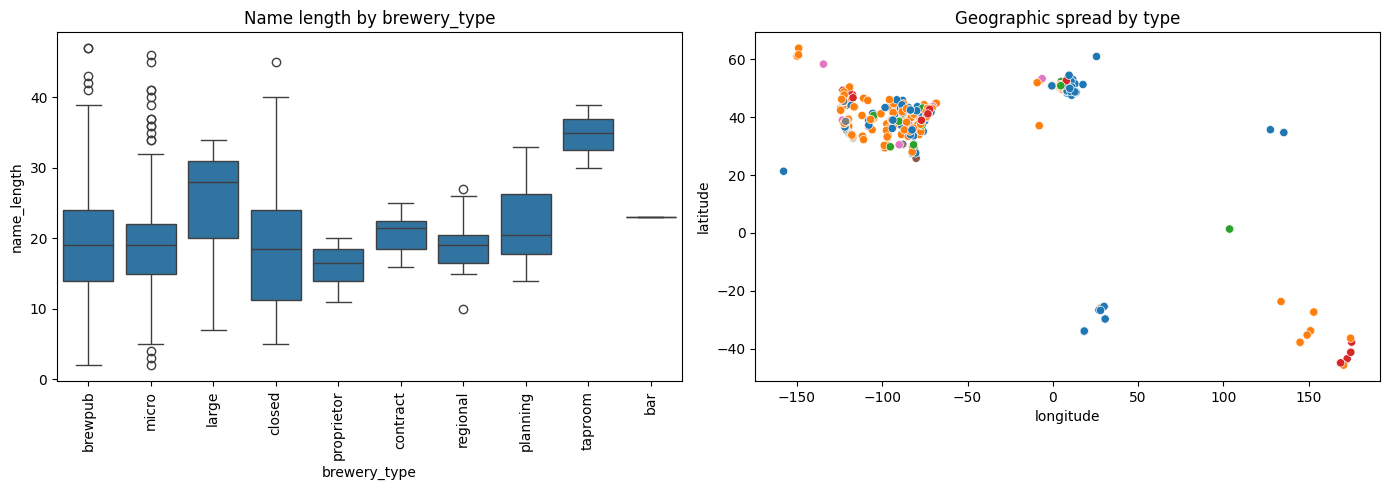

In [7]:

# Class balance
plt.figure(figsize=(10, 4))
df_raw[TARGET].value_counts().plot(kind="bar")
plt.title("Class balance: brewery_type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df_raw[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap of numeric features")
plt.tight_layout()
plt.show()

# Relationship plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_raw, x=TARGET, y="name_length", ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_title("Name length by brewery_type")

sns.scatterplot(data=df_raw, x="longitude", y="latitude", hue=TARGET, ax=axes[1], legend=False)
axes[1].set_title("Geographic spread by type")
plt.tight_layout()
plt.show()


In [8]:
# Cleaning decisions:
# - No missing target values (brewery_type always present).
# - latitude/longitude missing for 121/600 rows (~20%) -> imputed with the median,
#   since these are numeric coordinate fields and dropping the column would lose a
#   useful geographic signal; the column is not missing enough (<40-50%) to drop.
# - No exact duplicate rows found.
# - Rare classes: "bar" (1), "taproom" (3), "proprietor" (4) have too few examples for
#   a stratified split -> merged into an "other" bucket. "contract" (12) and
#   "regional" (11) are kept as-is since they clear the >=5 threshold.
# - No outlier removal: unusual lat/lon or long names are legitimate real breweries,
#   not data errors.
# - No categorical encoding needed beyond has_website/has_phone, which are already
#   binary numeric flags.

df_clean = df_raw.dropna(subset=[TARGET]).drop_duplicates().reset_index(drop=True)

for col in ["latitude", "longitude"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

rare_classes = df_clean[TARGET].value_counts()
rare_classes = rare_classes[rare_classes < 5].index.tolist()
df_clean[TARGET] = df_clean[TARGET].replace(rare_classes, "other")

print("Raw shape:", df_raw.shape, "-> Clean shape:", df_clean.shape)
print("Merged into 'other':", rare_classes)
print(df_clean[TARGET].value_counts())
df_clean.to_csv("clean_data.csv", index=False)
df_clean.head()


Raw shape: (600, 12) -> Clean shape: (600, 12)
Merged into 'other': ['proprietor', 'taproom', 'bar']
brewery_type
micro       297
brewpub     181
closed       34
planning     32
large        25
contract     12
regional     11
other         8
Name: count, dtype: int64


,id,name,brewery_type,city,state_province,country,latitude,longitude,has_website,has_phone,name_length,num_words_name
0,ae7b3174-8be8-4d53-a3a5-9b8240970eea,'s,brewpub,Kronach,Bayern,Germany,50.241246,11.327765,1,1,2,1
1,aa7cbe9b-3a0f-4888-9884-6186b0042b55,’t Drankorgel,micro,Mol,Vlaanderen,Belgium,51.176258,5.056955,1,1,13,2
2,1034754f-abf9-4b42-bd6d-37e110ba4b1a,'T Kroontje,micro,Lebbeke,Vlaanderen,Belgium,51.007888,4.091393,1,1,11,2
3,5128df48-79fc-4f0f-8b52-d06be54d0cec,(405) Brewing Co,micro,Norman,Oklahoma,United States,35.257389,-97.468182,1,1,16,3
4,9c5a66c8-cc13-416f-a5d9-0a769c87d318,(512) Brewing Co,micro,Austin,Texas,United States,41.508210,-85.537819,1,1,16,3


In [9]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import joblib, json

X = df_clean[FEATURES]
y = df_clean[TARGET]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
}

results = {}
trained = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="macro", zero_division=0)
    results[name] = {"accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1}
    trained[name] = model
    print(name, results[name])


logistic_regression {'accuracy': 0.525, 'precision_macro': 0.1346153846153846, 'recall_macro': 0.15069444444444444, 'f1_macro': 0.13757744071779535}
random_forest {'accuracy': 0.5666666666666667, 'precision_macro': 0.17188431723315445, 'recall_macro': 0.18680555555555556, 'f1_macro': 0.17457216888281846}


In [10]:
import numpy as np

best_name = max(results, key=lambda n: results[n]["f1_macro"])
best_model = trained[best_name]
best_preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, best_preds, labels=range(len(le.classes_)))

if hasattr(best_model, "feature_importances_"):
    importances = dict(zip(FEATURES, best_model.feature_importances_.tolist()))
else:
    importances = dict(zip(FEATURES, np.abs(best_model.coef_).mean(axis=0).tolist()))

print("Best model:", best_name)
print(results)

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

with open("model_metrics.json", "w") as f:
    json.dump({
        "all_model_results": results,
        "best_model": best_name,
        "confusion_matrix": cm.tolist(),
        "class_labels": le.classes_.tolist(),
        "feature_importance": importances,
        "features": FEATURES,
    }, f, indent=2)

print("Saved model.pkl, scaler.pkl, label_encoder.pkl, model_metrics.json")


Best model: random_forest
{'logistic_regression': {'accuracy': 0.525, 'precision_macro': 0.1346153846153846, 'recall_macro': 0.15069444444444444, 'f1_macro': 0.13757744071779535}, 'random_forest': {'accuracy': 0.5666666666666667, 'precision_macro': 0.17188431723315445, 'recall_macro': 0.18680555555555556, 'f1_macro': 0.17457216888281846}}
Saved model.pkl, scaler.pkl, label_encoder.pkl, model_metrics.json


In [11]:

from google.colab import files
for fname in ["raw_data.csv", "clean_data.csv", "model.pkl", "scaler.pkl", "label_encoder.pkl", "model_metrics.json"]:
    files.download(fname)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import zipfile
from google.colab import files

with zipfile.ZipFile("brewery_artifacts.zip", "w") as zf:
    for fname in ["clean_data.csv", "model.pkl", "scaler.pkl", "label_encoder.pkl", "model_metrics.json"]:
        zf.write(fname)

files.download("brewery_artifacts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:

from google.colab import files
for fname in ["clean_data.csv", "model.pkl", "scaler.pkl", "label_encoder.pkl", "model_metrics.json"]:
    files.download(fname)


In [13]:
from google.colab import files
files.download("raw_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>